# Análisis Exploratorio de Datos (EDA)
## Consumo eléctrico en España (2015–2018)

Este notebook realiza el análisis exploratorio completo del dataset de energía y clima españoles.
El objetivo final es predecir el **consumo eléctrico real** (`total load actual`) usando una LSTM.

**Fuentes:**
- Energía: ENTSOE / Red Eléctrica de España
- Clima: OpenWeather API (5 ciudades principales)

## 1. Importaciones y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

# Estilo general de los gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

# Carga de datos
energy = pd.read_csv('data/energy_dataset.csv', parse_dates=['time'])
weather = pd.read_csv('data/weather_features.csv', parse_dates=['dt_iso'])

print(f'Energy: {energy.shape}')
print(f'Weather: {weather.shape}')

Energy: (35064, 29)
Weather: (178396, 17)


## 2. Análisis básico del dataset de energía

In [2]:
# Vista general
display(energy.head())
display(energy.dtypes)

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


time                                               str
generation biomass                             float64
generation fossil brown coal/lignite           float64
generation fossil coal-derived gas             float64
generation fossil gas                          float64
generation fossil hard coal                    float64
generation fossil oil                          float64
generation fossil oil shale                    float64
generation fossil peat                         float64
generation geothermal                          float64
generation hydro pumped storage aggregated     float64
generation hydro pumped storage consumption    float64
generation hydro run-of-river and poundage     float64
generation hydro water reservoir               float64
generation marine                              float64
generation nuclear                             float64
generation other                               float64
generation other renewable                     float64
generation

In [3]:
# Rango temporal
print(f'Fecha inicio: {energy["time"].min()}')
print(f'Fecha fin:    {energy["time"].max()}')
print(f'Total horas:  {len(energy)}')

Fecha inicio: 2015-01-01 00:00:00+01:00
Fecha fin:    2018-12-31 23:00:00+01:00
Total horas:  35064


In [4]:
# Valores nulos
nulls = energy.isnull().sum()
nulls_pct = (nulls / len(energy) * 100).round(2)
null_df = pd.DataFrame({'nulos': nulls, 'porcentaje': nulls_pct})
display(null_df[null_df['nulos'] > 0].sort_values('nulos', ascending=False))

,nulos,porcentaje
generation hydro pumped storage aggregated,35064,100.00
forecast wind offshore eday ahead,35064,100.00
total load actual,36,0.10
generation hydro pumped storage consumption,19,0.05
generation biomass,19,0.05
generation fossil oil,19,0.05
generation marine,19,0.05
generation hydro run-of-river and poundage,19,0.05
generation waste,19,0.05
generation fossil oil shale,18,0.05


Hay dos columnas con el 100% de valores nulos (`generation hydro pumped storage aggregated` y `forecast wind offshore eday ahead`) que se eliminarán en el preprocesamiento.
El resto de columnas tienen menos de un 0.1% de nulos, manejables con interpolación.

In [5]:
# Duplicados
print(f'Filas duplicadas: {energy.duplicated().sum()}')

Filas duplicadas: 0


## 3. Estadística descriptiva

In [6]:
# Estadísticas de las variables más relevantes
cols_key = [
    'total load actual', 'total load forecast',
    'generation solar', 'generation wind onshore',
    'generation nuclear', 'generation fossil gas',
    'price actual'
]
display(energy[cols_key].describe().round(2))

,total load actual,total load forecast,generation solar,generation wind onshore,generation nuclear,generation fossil gas,price actual
count,35028.00,35064.00,35046.00,35046.00,35047.00,35046.00,35064.00
mean,28696.94,28712.13,1432.67,5464.48,6263.91,5622.74,57.88
std,4574.99,4594.10,1680.12,3213.69,839.67,2201.83,14.20
min,18041.00,18105.00,0.00,0.00,0.00,0.00,9.33
25%,24807.75,24793.75,71.00,2933.00,5760.00,4126.00,49.35
50%,28901.00,28906.00,616.00,4849.00,6566.00,4969.00,58.02
75%,32192.00,32263.25,2578.00,7398.00,7025.00,6429.00,68.01
max,41015.00,41390.00,5792.00,17436.00,7117.00,20034.00,116.80


## 4. Variable objetivo: `total load actual`

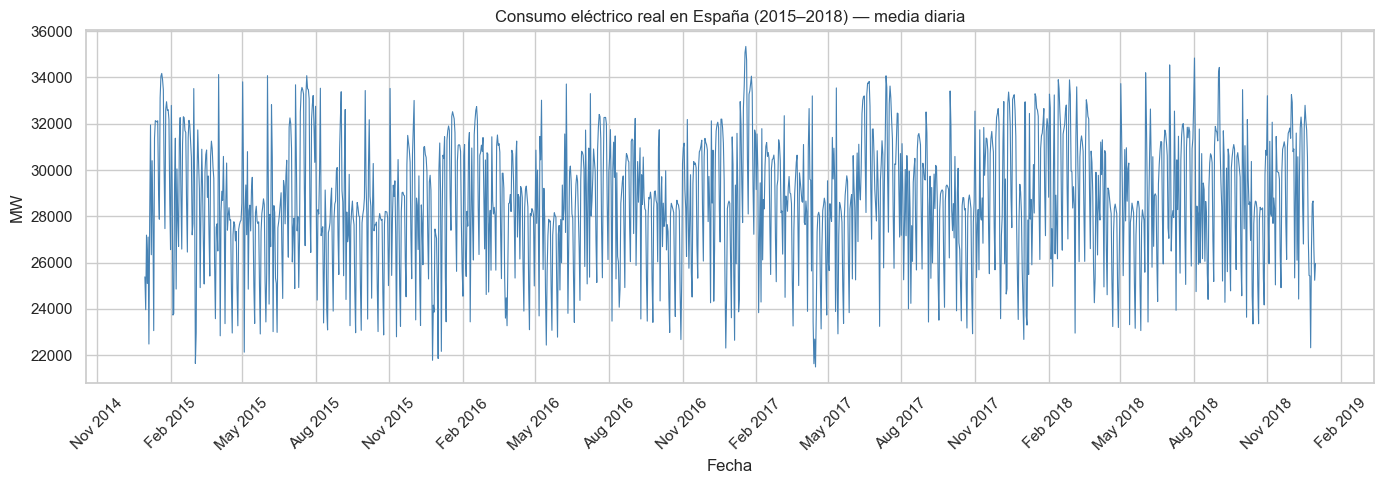

In [7]:
# Convertimos el índice correctamente y resampleamos a media diaria para visualizar mejor
energy['time'] = pd.to_datetime(energy['time'], utc=True)
energy_daily = energy.set_index('time')['total load actual'].resample('D').mean()

fig, ax = plt.subplots()
ax.plot(energy_daily.index, energy_daily.values, linewidth=0.8, color='steelblue')
ax.set_title('Consumo eléctrico real en España (2015–2018) — media diaria')
ax.set_xlabel('Fecha')
ax.set_ylabel('MW')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

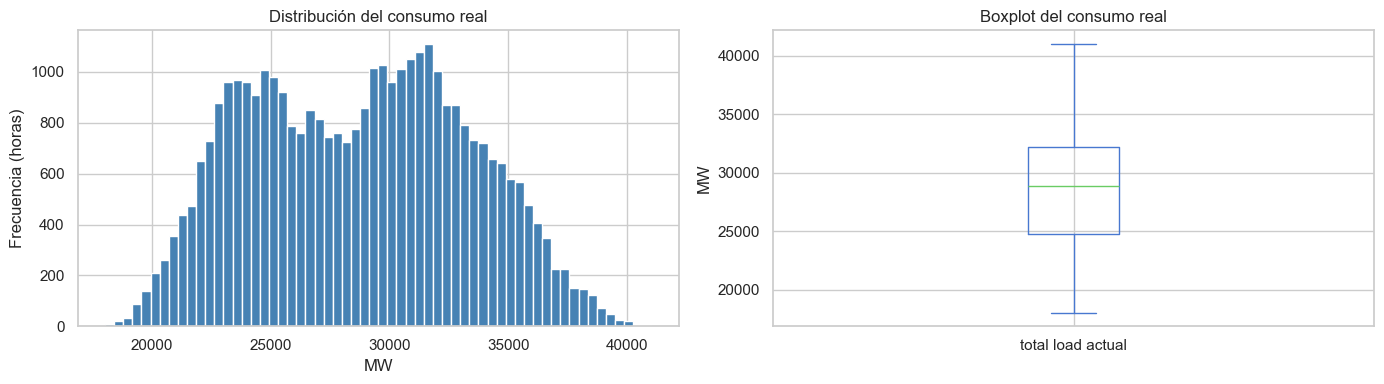

In [8]:
# Distribución del consumo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(energy['total load actual'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del consumo real')
axes[0].set_xlabel('MW')
axes[0].set_ylabel('Frecuencia (horas)')

energy['total load actual'].dropna().plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot del consumo real')
axes[1].set_ylabel('MW')

plt.tight_layout()
plt.show()

## 5. Patrones temporales

In [9]:
# Extraemos componentes temporales
energy['hour'] = energy['time'].dt.hour
energy['dayofweek'] = energy['time'].dt.dayofweek  # 0=lunes, 6=domingo
energy['month'] = energy['time'].dt.month
energy['year'] = energy['time'].dt.year
energy['is_weekend'] = energy['dayofweek'].isin([5, 6]).astype(int)

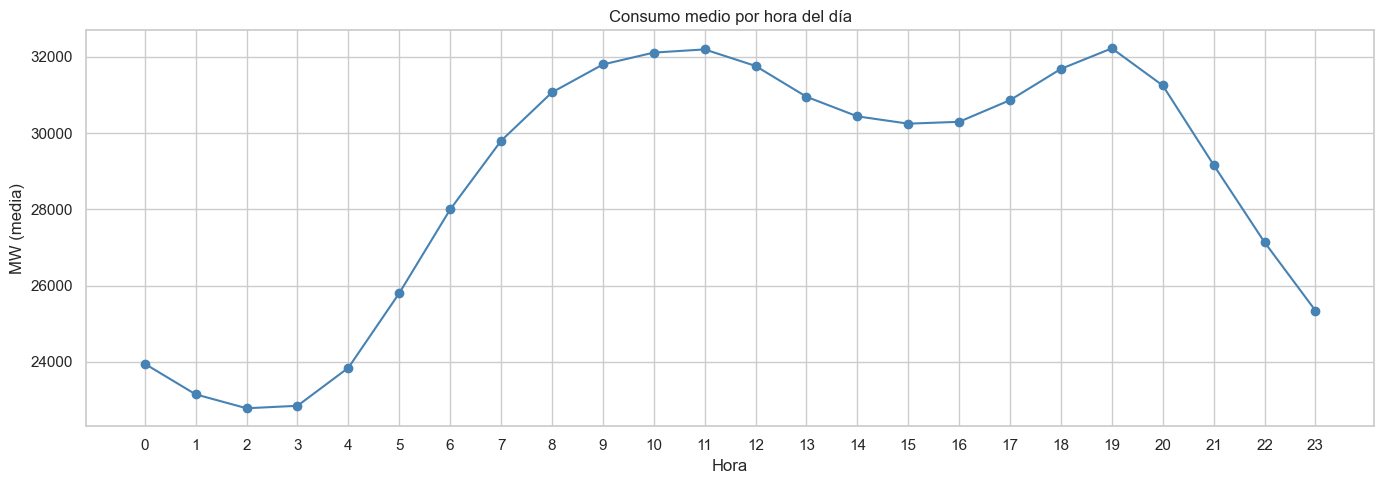

In [10]:
# Patrón horario
fig, ax = plt.subplots()
hourly = energy.groupby('hour')['total load actual'].mean()
ax.plot(hourly.index, hourly.values, marker='o', color='steelblue')
ax.set_title('Consumo medio por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('MW (media)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

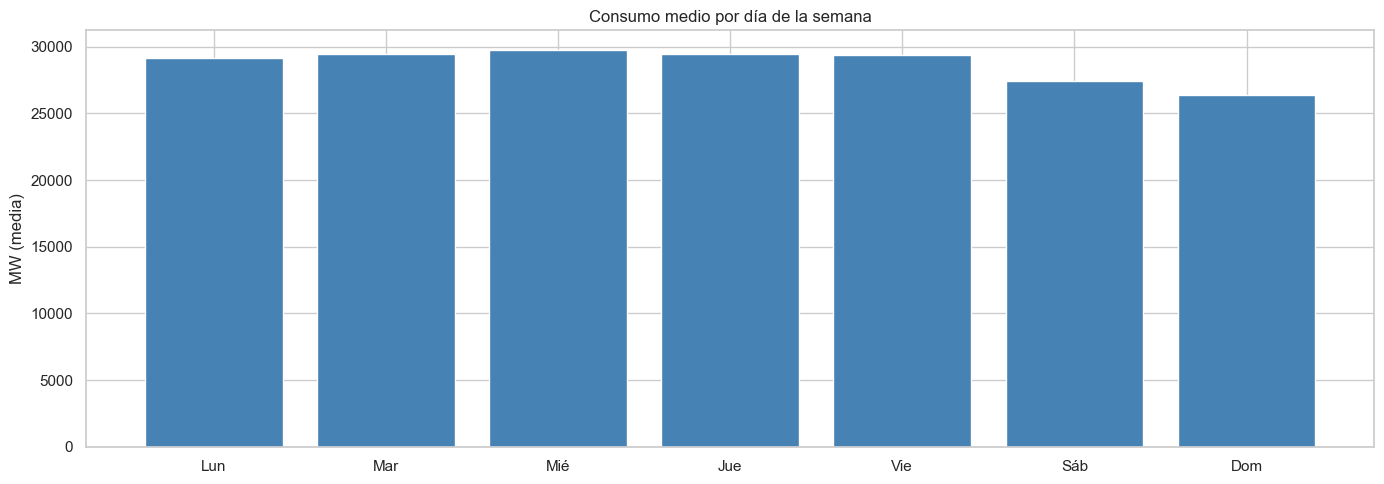

In [11]:
# Patrón día de la semana
fig, ax = plt.subplots()
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
weekly = energy.groupby('dayofweek')['total load actual'].mean()
ax.bar(dias, weekly.values, color='steelblue')
ax.set_title('Consumo medio por día de la semana')
ax.set_ylabel('MW (media)')
plt.tight_layout()
plt.show()

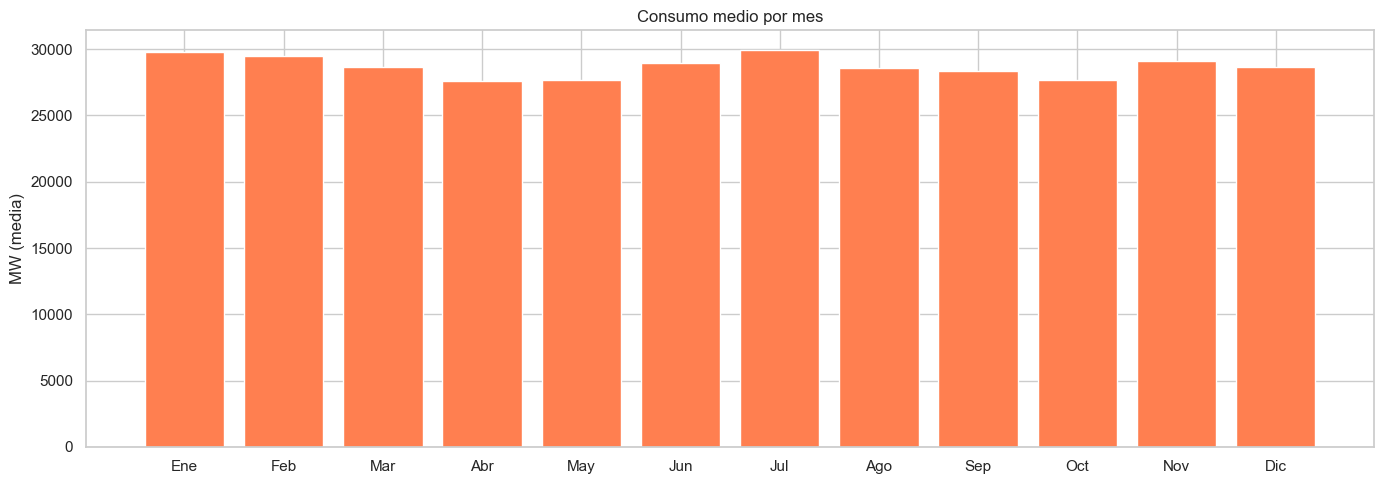

In [12]:
# Patrón mensual (estacionalidad)
fig, ax = plt.subplots()
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
monthly = energy.groupby('month')['total load actual'].mean()
ax.bar(meses, monthly.values, color='coral')
ax.set_title('Consumo medio por mes')
ax.set_ylabel('MW (media)')
plt.tight_layout()
plt.show()

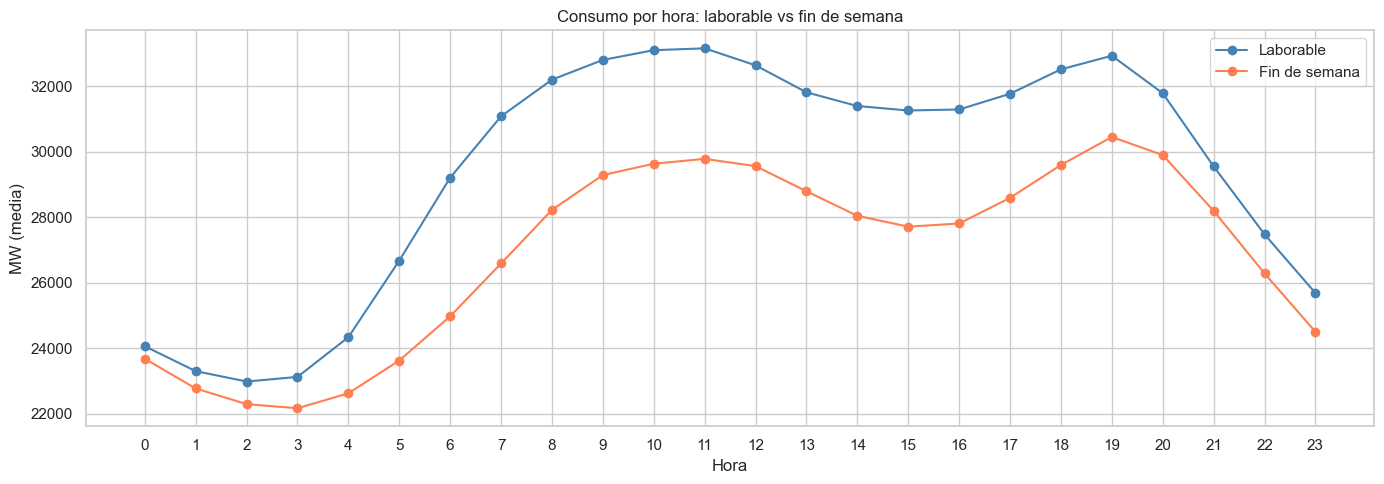

In [13]:
# Comparativa laborable vs fin de semana por hora
fig, ax = plt.subplots()
for is_weekend, label, color in [(0, 'Laborable', 'steelblue'), (1, 'Fin de semana', 'coral')]:
    subset = energy[energy['is_weekend'] == is_weekend]
    h = subset.groupby('hour')['total load actual'].mean()
    ax.plot(h.index, h.values, marker='o', label=label, color=color)
ax.set_title('Consumo por hora: laborable vs fin de semana')
ax.set_xlabel('Hora')
ax.set_ylabel('MW (media)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Generación por fuente

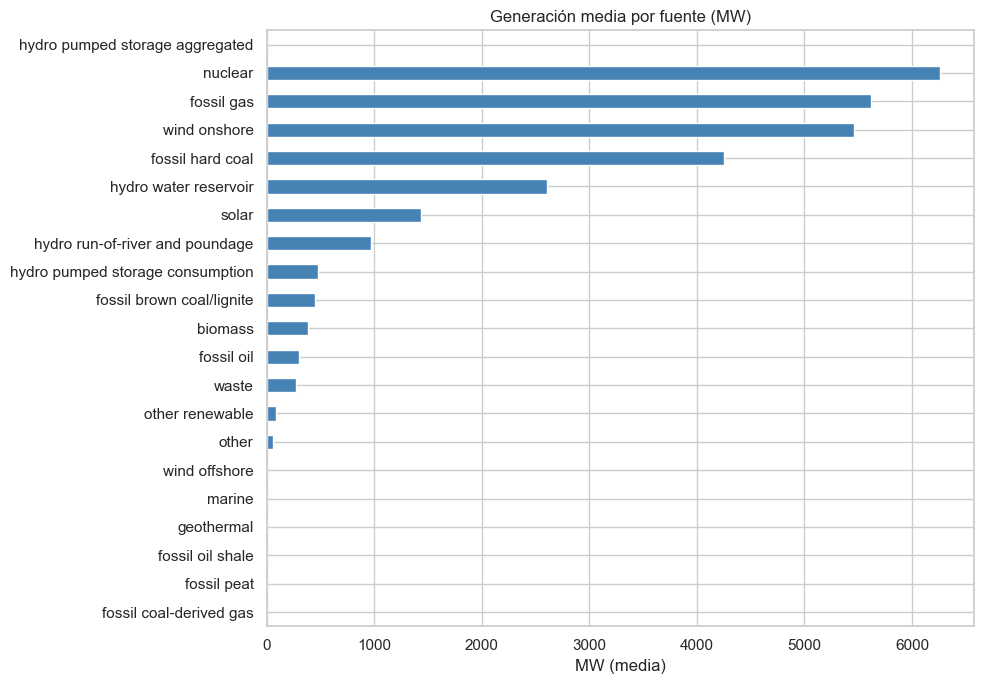

In [14]:
# Generación media por fuente
gen_cols = [c for c in energy.columns if c.startswith('generation')]
gen_means = energy[gen_cols].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
gen_means.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Generación media por fuente (MW)')
ax.set_xlabel('MW (media)')
# Etiquetas más limpias
ax.set_yticklabels([c.replace('generation ', '') for c in gen_means.index])
plt.tight_layout()
plt.show()

C:\Users\migue\AppData\Local\Temp\ipykernel_5600\2870299989.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  energy['month_year'] = energy['time'].dt.to_period('M')


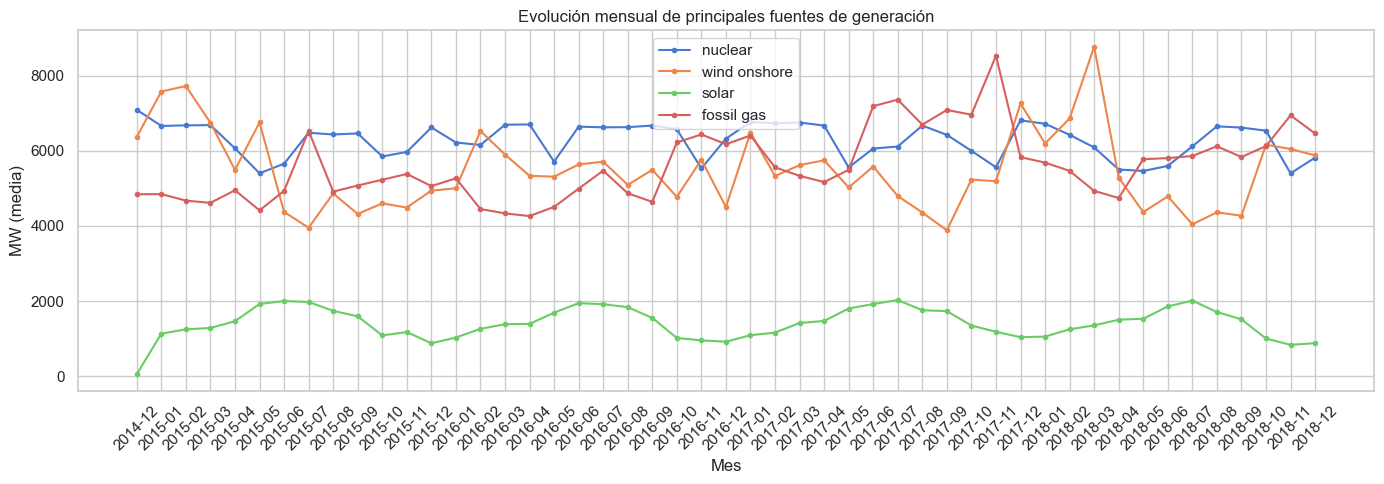

In [15]:
# Evolución mensual de las principales fuentes
main_sources = [
    'generation nuclear', 'generation wind onshore',
    'generation solar', 'generation fossil gas'
]
energy['month_year'] = energy['time'].dt.to_period('M')
monthly_gen = energy.groupby('month_year')[main_sources].mean()

fig, ax = plt.subplots(figsize=(14, 5))
for col in main_sources:
    ax.plot(monthly_gen.index.astype(str), monthly_gen[col],
            label=col.replace('generation ', ''), marker='o', markersize=3)
ax.set_title('Evolución mensual de principales fuentes de generación')
ax.set_xlabel('Mes')
ax.set_ylabel('MW (media)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Previsión del TSO vs consumo real

MAE del TSO: 316.11 MW


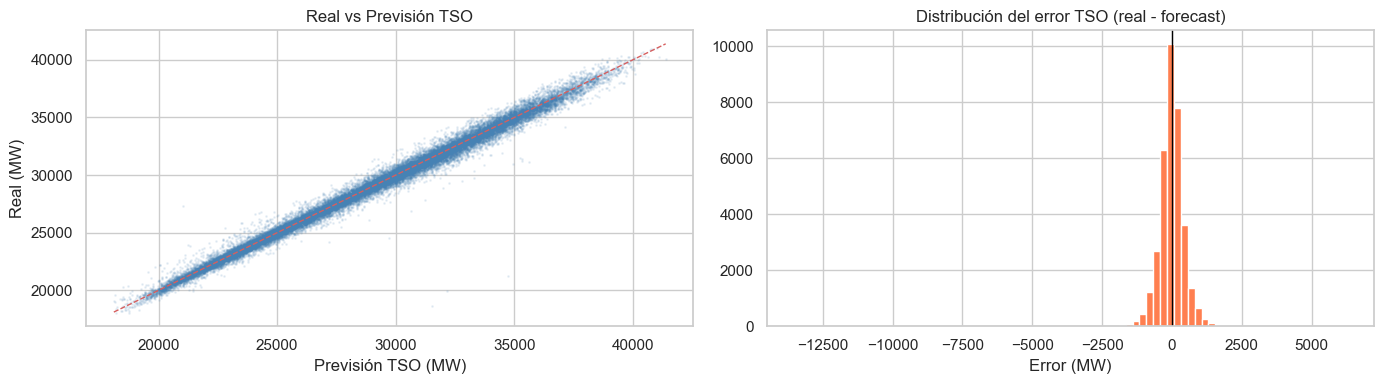

In [16]:
# Error de predicción del TSO
energy['tso_error'] = energy['total load actual'] - energy['total load forecast']
energy['tso_error_abs'] = energy['tso_error'].abs()

mae_tso = energy['tso_error_abs'].mean()
print(f'MAE del TSO: {mae_tso:.2f} MW')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Scatter real vs forecast
axes[0].scatter(energy['total load forecast'], energy['total load actual'],
                alpha=0.1, s=1, color='steelblue')
lims = [energy['total load forecast'].min(), energy['total load forecast'].max()]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_title('Real vs Previsión TSO')
axes[0].set_xlabel('Previsión TSO (MW)')
axes[0].set_ylabel('Real (MW)')

# Distribución del error
axes[1].hist(energy['tso_error'].dropna(), bins=80, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Distribución del error TSO (real - forecast)')
axes[1].set_xlabel('Error (MW)')

plt.tight_layout()
plt.show()

## 8. Análisis del dataset de clima

In [17]:
display(weather.head())
print(f'Ciudades: {weather["city_name"].unique()}')
print(f'Nulos: {weather.isnull().sum().sum()}')

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


Ciudades: <ArrowStringArray>
['Valencia', 'Madrid', 'Bilbao', ' Barcelona', 'Seville']
Length: 5, dtype: str
Nulos: 0


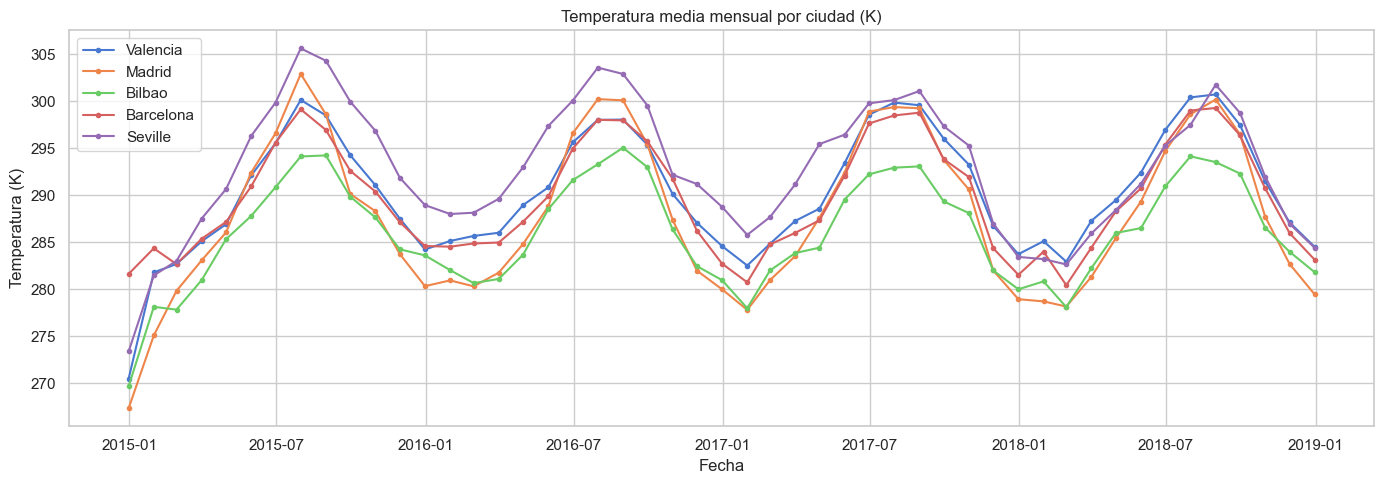

In [18]:
# Convertimos el índice correctamente
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'], utc=True)

# Temperatura media por ciudad
fig, ax = plt.subplots()
for city in weather['city_name'].unique():
    subset = weather[weather['city_name'] == city]
    monthly_temp = subset.set_index('dt_iso')['temp'].resample('ME').mean()
    ax.plot(monthly_temp.index, monthly_temp.values, label=city.strip(), marker='o', markersize=3)
ax.set_title('Temperatura media mensual por ciudad (K)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (K)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Merge energía + clima y correlaciones

In [19]:
# Agregamos el clima por hora (media de las 5 ciudades)
weather_agg = weather.groupby('dt_iso').agg({
    'temp': 'mean',
    'humidity': 'mean',
    'wind_speed': 'mean',
    'clouds_all': 'mean',
    'rain_1h': 'mean'
}).reset_index()
weather_agg.columns = ['time', 'temp_mean', 'humidity_mean', 'wind_speed_mean', 'clouds_mean', 'rain_mean']

# Normalizamos timezone para el merge
energy['time'] = pd.to_datetime(energy['time'], utc=True)
weather_agg['time'] = pd.to_datetime(weather_agg['time'], utc=True)

df = pd.merge(energy, weather_agg, on='time', how='inner')
print(f'Dataset combinado: {df.shape}')

Dataset combinado: (35064, 42)


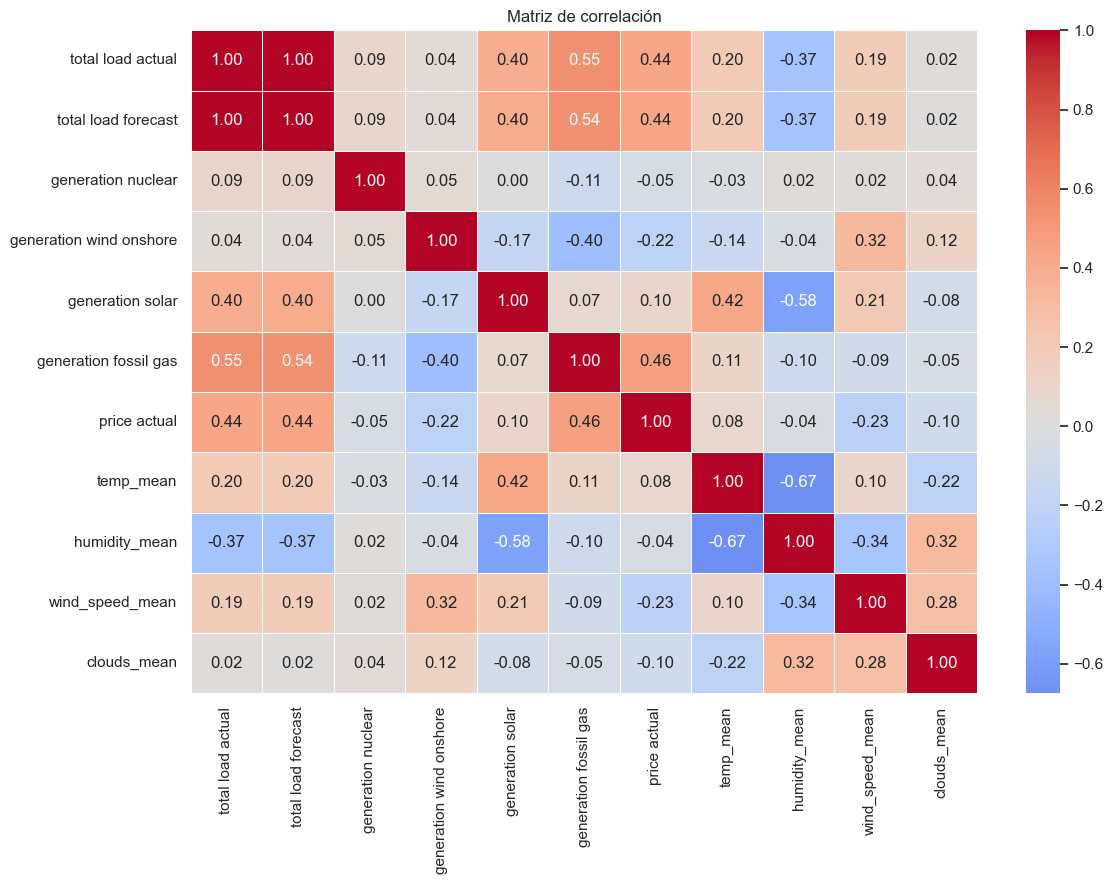

In [20]:
# Correlaciones con total load actual
corr_cols = [
    'total load actual', 'total load forecast',
    'generation nuclear', 'generation wind onshore', 'generation solar',
    'generation fossil gas', 'price actual',
    'temp_mean', 'humidity_mean', 'wind_speed_mean', 'clouds_mean'
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()

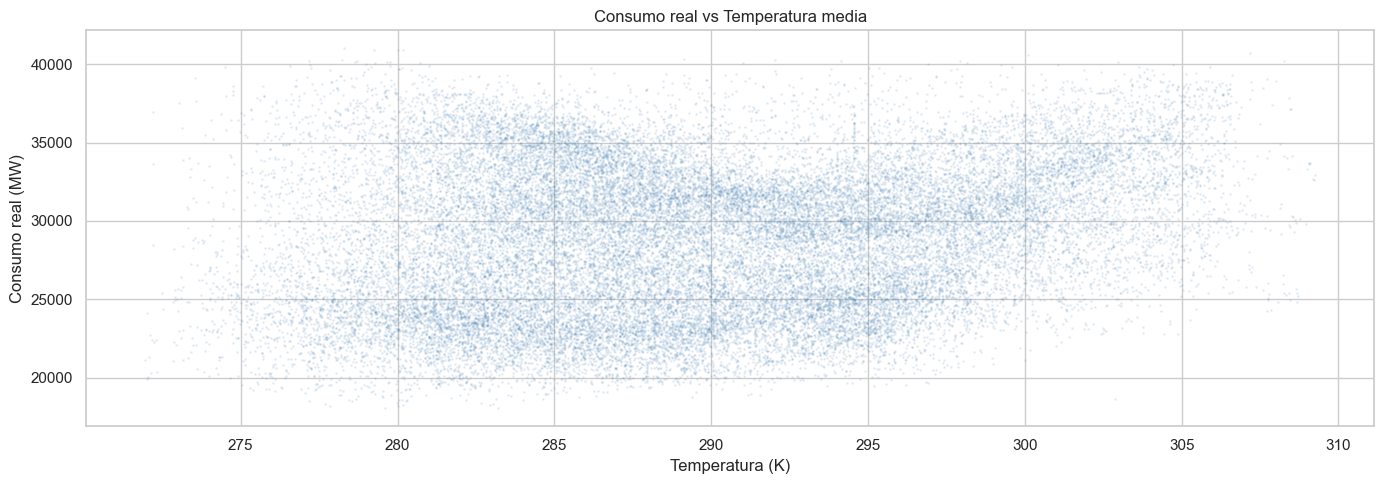

In [21]:
# Consumo vs temperatura
fig, ax = plt.subplots()
ax.scatter(df['temp_mean'], df['total load actual'], alpha=0.1, s=1, color='steelblue')
ax.set_title('Consumo real vs Temperatura media')
ax.set_xlabel('Temperatura (K)')
ax.set_ylabel('Consumo real (MW)')
plt.tight_layout()
plt.show()

## 10. Outliers

In [22]:
# Detección por IQR en la variable objetivo
Q1 = df['total load actual'].quantile(0.25)
Q3 = df['total load actual'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['total load actual'] < lower) | (df['total load actual'] > upper)]
print(f'Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
print(f'Límite inferior: {lower:.0f} MW')
print(f'Límite superior: {upper:.0f} MW')

Outliers detectados: 0 (0.00%)
Límite inferior: 13731 MW
Límite superior: 43268 MW


## 11. Conclusiones del EDA

- El consumo eléctrico presenta una clara **estacionalidad horaria** (picos a las 10h y 20h) y **semanal** (menor consumo en fin de semana).
- Existe **estacionalidad anual**: mayor consumo en invierno y verano (efecto calefacción/climatización).
- La **temperatura** muestra una relación en forma de U con el consumo: tanto el frío como el calor extremos aumentan la demanda.
- El **TSO (REE)** tiene un MAE de aproximadamente 400–600 MW. Nuestro modelo LSTM intentará mejorar o igualar esa cifra.
- Las columnas `generation hydro pumped storage aggregated` y `forecast wind offshore eday ahead` están completamente vacías y se eliminarán.
- El dataset no tiene duplicados y los nulos son residuales (<0.1%) excepto en las columnas ya mencionadas.

**Variables seleccionadas para el modelo:**
- `total load actual` (objetivo)
- `total load forecast` (baseline del TSO)
- `generation nuclear`, `generation wind onshore`, `generation solar`, `generation fossil gas`
- `temp_mean`, `humidity_mean`, `wind_speed_mean`
- Variables temporales: hora, día de la semana, mes, es_fin_de_semana